---

# ASSIGNMENT 5: ADVANCED BAR CHARTS

---

>---
>
>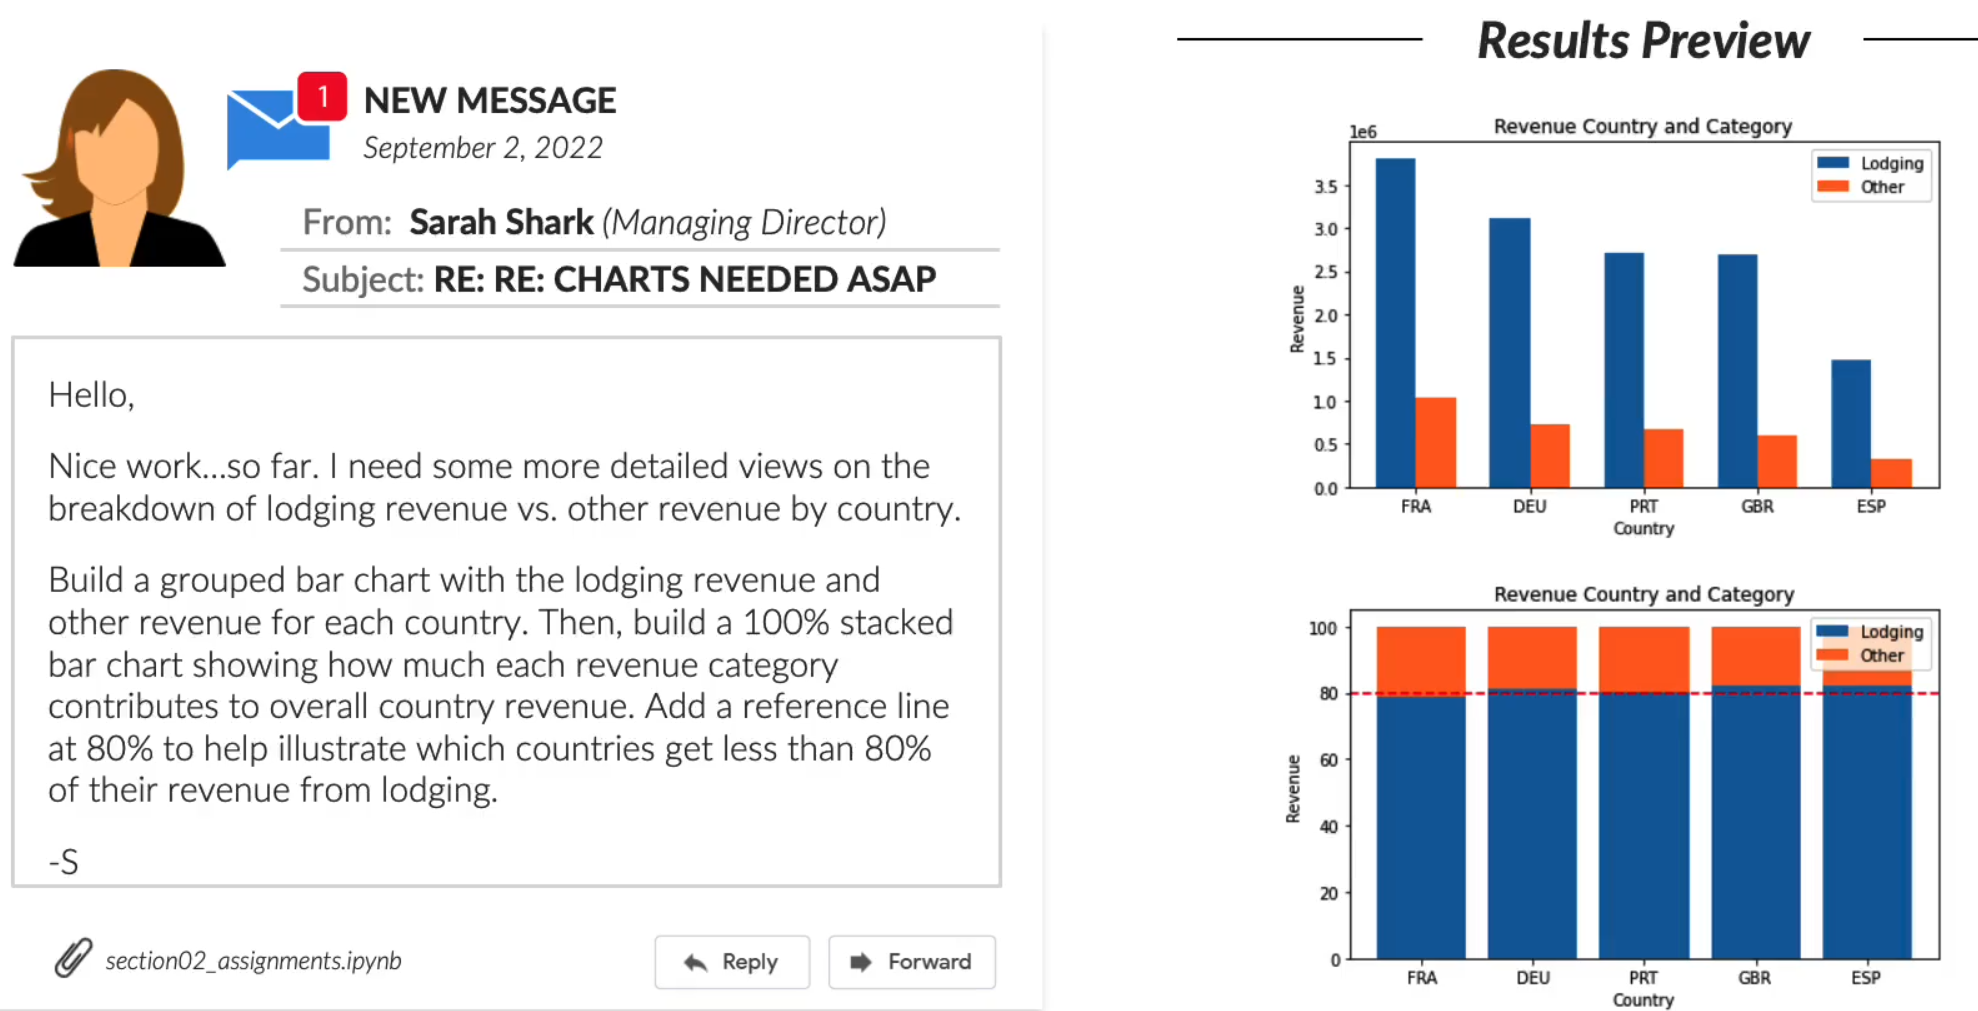
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('../Data/HotelCustomersDataset.xlsx')

df['date'] = (pd.to_datetime('2018-12-31') - pd.to_timedelta(df.DaysSinceCreation, unit='D')).astype('datetime64[ns]')
df = df[['Nationality', 'OtherRevenue', 'LodgingRevenue', ]]

display(df.head(), df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Nationality     83590 non-null  object 
 1   OtherRevenue    83590 non-null  float64
 2   LodgingRevenue  83590 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.9+ MB


,Nationality,OtherRevenue,LodgingRevenue
0,PRT,105.3,371.0
1,PRT,53.0,280.0
2,DEU,0.0,0.0
3,FRA,60.0,240.0
4,FRA,0.0,0.0


None

In [3]:
df1 = (df
    .groupby('Nationality')
    .agg({'OtherRevenue':'sum', 'LodgingRevenue':'sum'})
    .sort_values(by=['LodgingRevenue', 'OtherRevenue'], ascending=[False, False]).head()
)
df1

,OtherRevenue,LodgingRevenue
Nationality,,
FRA,1033166.30,3809315.59
DEU,725541.53,3113382.55
PRT,665634.58,2715008.72
GBR,591212.77,2693123.61
ESP,319840.82,1475909.33


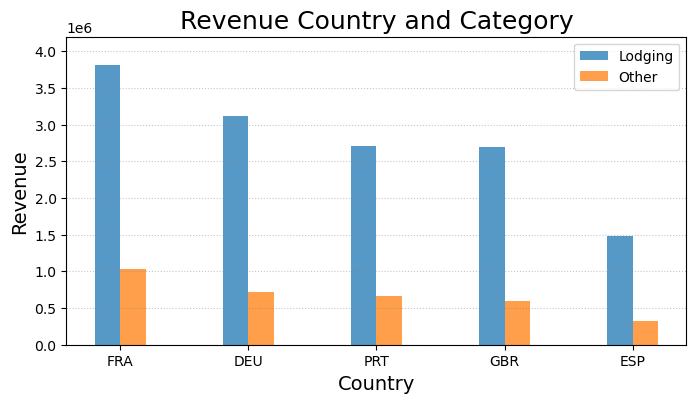

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

width = 0.2
x = np.arange(len(df1.index))

ax.bar(x - width/2, df1.LodgingRevenue, label='Lodging',
       width=width, alpha=0.75)

ax.bar(x + width/2, df1.OtherRevenue, label='Other',
       width=width, alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(df1.index)

ax.set_ylim(0, 4.2*1e6)
ax.grid(axis='y', c='gray', alpha=0.45, ls=':', )

ax.legend(loc=('upper right'))

ax.set_title('Revenue Country and Category', fontsize=18)
ax.set_xlabel('Country', fontsize=14)
ax.set_ylabel('Revenue', fontsize=14)

plt.show()

In [5]:
df2 = df1.apply(lambda x: x*100/sum(x), axis=1)
df2

,OtherRevenue,LodgingRevenue
Nationality,,
FRA,21.335471,78.664529
DEU,18.899606,81.100394
PRT,19.689583,80.310417
GBR,18.000981,81.999019
ESP,17.810987,82.189013


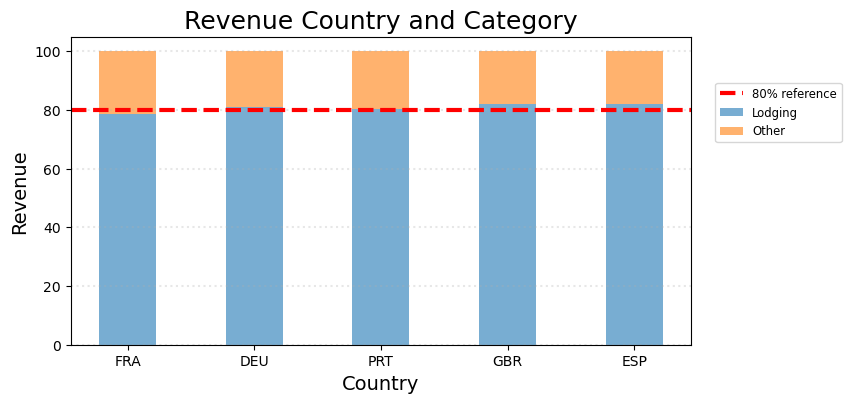

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(df2.index, df2.LodgingRevenue, label='Lodging',
       width=0.45, alpha=0.6)

ax.bar(df2.index, df2.OtherRevenue, label='Other',
       alpha=0.6, width=0.45, bottom=df2.LodgingRevenue)

ax.axhline(y=80, ls='--', color='red', linewidth=3, 
           label='80% reference')
ax.legend(bbox_to_anchor=(1.03, 0.87), 
          fontsize='small')
ax.grid(axis='y', ls=':', linewidth=1.5, alpha=0.3)

ax.set_title('Revenue Country and Category', fontsize=18)
ax.set_xlabel('Country', fontsize=14)
ax.set_ylabel('Revenue', fontsize=14)

plt.show()